In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import autograd.numpy as anp
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
from IPython.display import display, clear_output
from autograd_utils import make_filter_and_project, make_erosion_dilation_penalty, value_and_grad
from solver_linear_elasticity import FE, lk
from solver_thermal_conduction import FE_thermal, lk_thermal
from mma_optimizer import MMA_update

In [2]:
def schedule_beta(max_iter, start_iter, ramp_iter, beta_min, beta_max):
    steps = np.arange(max_iter)
    beta = np.empty_like(steps, dtype=float)

    left = steps <= start_iter
    right = steps > (start_iter + ramp_iter)
    mid = ~(left | right)

    beta[left] = beta_min
    beta[right] = beta_max

    if np.any(mid):
        ramp_len = ramp_iter
        if ramp_len <= 0:
            beta[mid] = beta_max
        else:
            t = (steps[mid] - start_iter) / ramp_len
            beta[mid] = beta_min + t * (beta_max - beta_min)
    return beta

def make_projection_pipeline(rmin, beta_fab=20.0, eta=0.5, delta_eta_fab=0.3):
    filter_project = make_filter_and_project(
        radius=rmin,
        dl=1.0,
        beta=beta_fab,
        eta=eta,
        filter_type='conic',
    )

    erode_dilate_penalty = make_erosion_dilation_penalty(
        radius=rmin,
        dl=1.0,
        delta_eta=delta_eta_fab,
        beta=beta_fab,
    )

    def pre_process(arr, beta):
        return filter_project(arr, beta=beta)

    def morph(arr, eta):
        return filter_project(arr, eta=eta)

    def erode(arr):
        return morph(arr, eta=1.0 - delta_eta_fab)

    def dilate(arr):
        return morph(arr, eta=0.0 + delta_eta_fab)

    def fabrication_penalty(arr):
        return erode_dilate_penalty(arr)

    return pre_process, erode, dilate, fabrication_penalty

In [3]:
# Save optimization history to pkl file
def save_history(history_dict: dict, fname: str) -> None:
    """Save the optimization history to a pickle file."""
    with open(fname, "wb") as file:
        pickle.dump(history_dict, file)

In [ ]:
def _compute_element_sensitivities_elasticity(nelx, nely, U, Lambda, KE):
    """Compute element mutual energy for 2D elasticity (8 DOFs/element)."""
    ce = np.zeros((nely, nelx))
    for ely in range(nely):
        for elx in range(nelx):
            n1 = (nely + 1) * elx + (ely + 1)
            n2 = (nely + 1) * (elx + 1) + (ely + 1)
            edof = np.array([
                2 * n1 - 2, 2 * n1 - 1,
                2 * n2 - 2, 2 * n2 - 1,
                2 * n2,     2 * n2 + 1,
                2 * n1,     2 * n1 + 1,
            ], dtype=int)
            ce[ely, elx] = Lambda[edof] @ KE @ U[edof]
    return ce


def _compute_element_sensitivities_thermal(nelx, nely, T, KE_t):
    """Compute element thermal compliance (4 DOFs/element)."""
    ce = np.zeros((nely, nelx))
    for elx in range(nelx):
        for ely in range(nely):
            n1 = (nely + 1) * elx + ely
            n2 = (nely + 1) * (elx + 1) + ely
            edof = np.array([n1, n2, n2 + 1, n1 + 1], dtype=int)
            Te = T[edof]
            ce[ely, elx] = Te @ KE_t @ Te
    return ce

def top(
    nelx,
    nely,
    volfrac,
    rmin,
    # --- physics selector ---
    physics,                            # 'elasticity' or 'thermal'
    bc              =None,              # 'cantilever', 'mbb', or 'mechanism' (elasticity only)
    # --- shared optimizer params ---
    penal           =3.0,
    tol             =0.03,
    max_iter        =150,
    start_iter      =9,
    ramp_iter       =20,
    beta_min        =1.0,
    beta_max        =10.0,
    delta_eta_fab   =0.3,
    fab_tol_start   =1.0,
    fab_tol_end     =0.025,
    move            =1.0,
    move_locked     =0.25,
    morph_blend     =(0.5, 0.5),        # morph-locked blending weights (w_open, w_close)
    normalize_obj   =True,
    fab_plateau_window=0,               # fab plateau detection (window=0 disables)
    fab_plateau_rel_decline_tol=1.0,
    c_fab            =500.0,            # fabrication constraint penalty coefficient for MMA
    # --- elasticity / mechanism params ---
    k_in            =1.0,
    k_out           =0.02,
    
    # --- material interpolation ---
    E0              =1.0,
    Emin            =1e-6,
    
    # --- thermal params ---
    q               =0.01,
    sink_width_frac =0.1,
    sink_value      =1e-6,
):
    """
    Parameters
    ----------
    physics : str
        ``'elasticity'`` (linear elasticity, supports mechanism/cantilever/mbb)
        or ``'thermal'`` (steady-state heat conduction).
    morph_blend : tuple (w_open, w_close)
        Weights for open / close images when ``morph_locked_i=True``.
        Elasticity default ``(0.5, 0.5)``; thermal typical ``(1.0, 0.0)``.
    normalize_obj : bool
        Normalize objective and its gradient by the first iteration value.
    fab_plateau_window : int
        Rolling window for fab penalty plateau detection. 0 disables.
    fab_plateau_rel_decline_tol : float
        Max relative decline over the window to count as "plateaued".
    E0 : float
        Solid material Young's modulus (SIMP interpolation).
    Emin : float
        Void material Young's modulus (SIMP interpolation).
    """

    # --- Capture non-default input parameters ---
    _defaults = dict(
        bc=None, penal=3.0, tol=0.03, max_iter=150, start_iter=9, ramp_iter=20,
        beta_min=1.0, beta_max=10.0, delta_eta_fab=0.3, fab_tol_start=1.0,
        fab_tol_end=0.025, move=1.0, move_locked=0.25, morph_blend=(0.5, 0.5),
        normalize_obj=True, fab_plateau_window=0, fab_plateau_rel_decline_tol=1.0,
        c_fab=500.0, k_in=1.0, k_out=0.02, E0=1.0, Emin=1e-6,
        q=0.01, sink_width_frac=0.1, sink_value=1e-6,
    )
    _actuals = dict(
        nelx=nelx, nely=nely, volfrac=volfrac, rmin=rmin, physics=physics,
        bc=bc, penal=penal, tol=tol, max_iter=max_iter, start_iter=start_iter,
        ramp_iter=ramp_iter, beta_min=beta_min, beta_max=beta_max,
        delta_eta_fab=delta_eta_fab, fab_tol_start=fab_tol_start,
        fab_tol_end=fab_tol_end, move=move, move_locked=move_locked,
        morph_blend=morph_blend, normalize_obj=normalize_obj,
        fab_plateau_window=fab_plateau_window,
        fab_plateau_rel_decline_tol=fab_plateau_rel_decline_tol, c_fab=c_fab,
        k_in=k_in, k_out=k_out, E0=E0, Emin=Emin, q=q,
        sink_width_frac=sink_width_frac, sink_value=sink_value,
    )
    # Required params + any that differ from defaults
    params = {k: v for k, v in _actuals.items() if k not in _defaults or _defaults[k] != v}

    is_thermal = (physics == 'thermal')
    is_mechanism = (not is_thermal) and (bc == 'mechanism')
    w_open, w_close = morph_blend

    # --- Generate unique history file for this run ---
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs("data", exist_ok=True)
    history_fname = f"data/topopt_{timestamp}.pkl"

    # --- Physics-dependent element stiffness (computed once) ---
    if is_thermal:
        KE_phys = lk_thermal()
    else:
        KE_phys = lk()

    # --- Initialise design ---
    x = volfrac * np.ones((nely, nelx))

    # --- Passive solid regions (mechanism only) ---
    n_passive = int(np.ceil(rmin))
    passive_solid = np.zeros((nely, nelx), dtype=bool)
    if is_mechanism:
        passive_solid[:n_passive, :n_passive] = True
        passive_solid[:n_passive, nelx - n_passive:] = True
        x[passive_solid] = 1.0

    # --- State variables ---
    loop = 0
    change_i = 1.0
    low = x.copy()
    upp = x.copy()
    xold1 = x.copy()
    xold2 = x.copy()
    morph_locked_i = False

    comp_hist = []
    comp_norm_hist = []
    vol_hist = []
    change_hist = []
    fab_pen_hist = []
    fab_tol_hist = []
    beta_hist = []

    x_raw_hist = []
    x_proj_hist = []
    x_open_hist = []
    x_close_hist = []
    x_phys_hist = []

    beta_schedule = schedule_beta(max_iter, start_iter, ramp_iter, beta_min, beta_max)
    fab_tol_i = fab_tol_start
    comp_ref_i = None

    pre_process, erode, dilate, fabrication_penalty = make_projection_pipeline(
        rmin, beta_fab=beta_max, eta=0.5, delta_eta_fab=delta_eta_fab
    )

    fig, axs = plt.subplots(1, 5, figsize=(20, 3))

    fab_pen = 1.0
    volume = 1.0

    # --- Helper: blend physical density ---
    def _blend(proj, opened, closed, locked):
        if not locked:
            return proj
        return w_open * opened + w_close * closed

    # --- Main loop ---
    while loop < max_iter and (
        change_i > tol or fab_pen > fab_tol_end
    ):
        loop += 1
        xold = x.copy()
        beta_i = beta_schedule[loop - 1]

        # Projection + morphology
        x_proj = np.clip(np.asarray(pre_process(anp.array(x), beta=beta_i)), 0.0, 1.0)
        x_open = np.clip(np.asarray(dilate(erode(anp.array(x_proj)))), 0.0, 1.0)
        x_close = np.clip(np.asarray(erode(dilate(anp.array(x_proj)))), 0.0, 1.0)
        x_phys = _blend(x_proj, x_open, x_close, morph_locked_i)

        # --- FE solve ---
        if is_thermal:
            T = FE_thermal(
                nelx=nelx, nely=nely, x=x_phys, penal=penal,
                q=q, sink_width_frac=sink_width_frac,
                sink_value=sink_value, k_max=E0, k_min=Emin,
            )
            U = T
            Lambda = T  # self-adjoint
        else:
            if is_mechanism:
                U, Lambda, dof_out_x = FE(nelx, nely, x_phys, penal, bc=bc, k_in=k_in, k_out=k_out, E0=E0, Emin=Emin)
            else:
                U = FE(nelx, nely, x_phys, penal, bc=bc, E0=E0, Emin=Emin)
                Lambda = U

        # --- Element sensitivity energy ---
        if is_thermal:
            ce = _compute_element_sensitivities_thermal(nelx, nely, U, KE_phys)
        else:
            ce = _compute_element_sensitivities_elasticity(nelx, nely, U, Lambda, KE_phys)

        ce_anp = anp.array(ce)

        # --- AD closures (capture current beta_i, morph_locked_i) ---
        def projected_sets(x_var, _beta=beta_i):
            x_var_proj = anp.clip(pre_process(x_var, beta=_beta), 0.0, 1.0)
            x_var_open = anp.clip(dilate(erode(x_var_proj)), 0.0, 1.0)
            x_var_close = anp.clip(erode(dilate(x_var_proj)), 0.0, 1.0)
            return x_var_proj, x_var_open, x_var_close

        def _blend_ad(proj, opened, closed, _locked=morph_locked_i):
            if not _locked:
                return proj
            return w_open * opened + w_close * closed

        def volume_constraint(x_var, _beta=beta_i, _locked=morph_locked_i):
            x_var_proj = anp.clip(pre_process(x_var, beta=_beta), 0.0, 1.0)
            x_var_open = anp.clip(dilate(erode(x_var_proj)), 0.0, 1.0)
            x_var_close = anp.clip(erode(dilate(x_var_proj)), 0.0, 1.0)
            x_var_phys = _blend_ad(x_var_proj, x_var_open, x_var_close, _locked)
            return anp.mean(x_var_phys) / volfrac - 1.0

        def objective(x_var, _beta=beta_i, _locked=morph_locked_i, _ce=ce_anp):
            x_var_proj = anp.clip(pre_process(x_var, beta=_beta), 0.0, 1.0)
            x_var_open = anp.clip(dilate(erode(x_var_proj)), 0.0, 1.0)
            x_var_close = anp.clip(erode(dilate(x_var_proj)), 0.0, 1.0)
            x_var_phys = _blend_ad(x_var_proj, x_var_open, x_var_close, _locked)
            Ee = Emin + (x_var_phys ** penal) * (E0 - Emin)
            return anp.sum(Ee * _ce)

        def fabrication_constraint(x_var, _beta=beta_i, _fab_tol=fab_tol_i):
            x_var_proj = anp.clip(pre_process(x_var, beta=_beta), 0.0, 1.0)
            return fabrication_penalty(x_var_proj) - _fab_tol

        # --- Objective gradient via AD ---
        c_auto, dc_raw = value_and_grad(objective)(x)
        c = float(c_auto)

        # Normalization
        if normalize_obj:
            if comp_ref_i is None:
                comp_ref_i = max(abs(c), 1e-12)
            c_norm = c / comp_ref_i
            scale = comp_ref_i
        else:
            if comp_ref_i is None:
                comp_ref_i = 1.0
            c_norm = c
            scale = 1.0

        # Sensitivity sign: mechanism wants to maximize negative mutual PE,
        # all others minimize (flip sign for MMA which minimizes).
        if is_mechanism:
            dc = np.array(dc_raw) / scale
        else:
            dc = -np.array(dc_raw) / scale

        # Mechanism: report output displacement as the displayed objective
        if is_mechanism:
            c = float(np.mean(U[dof_out_x]))
            c_norm = c  # raw displacement for display
            
        # --- Constraint gradients via AD ---
        fval_vol, dfdx_vol = value_and_grad(volume_constraint)(x)
        fval_fab, dfdx_fab = value_and_grad(fabrication_constraint)(x)

        # Zero out sensitivities for passive solid elements (mechanism)
        if is_mechanism:
            dc[passive_solid] = 0.0
            dfdx_vol = np.array(dfdx_vol)
            dfdx_vol[passive_solid] = 0.0
            dfdx_fab = np.array(dfdx_fab)
            dfdx_fab[passive_solid] = 0.0

        fvals = np.array([float(fval_vol), float(fval_fab)])
        dfdx = np.vstack([
            np.array(dfdx_vol).ravel()[np.newaxis, :],
            np.array(dfdx_fab).ravel()[np.newaxis, :],
        ])
        move_i = move_locked if morph_locked_i else move
        x, low, upp = MMA_update(
            x, dc, fvals, dfdx, low, upp, xold1, xold2, loop, move=move_i, c_fab=c_fab
        )
        xold2 = xold1
        xold1 = xold

        # Enforce passive solid regions after MMA update (mechanism)
        if is_mechanism:
            x[passive_solid] = 1.0

        # --- Post-update projections ---
        x_proj_new = np.clip(np.asarray(pre_process(anp.array(x), beta=beta_i)), 0.0, 1.0)
        x_open_new = np.clip(np.asarray(dilate(erode(anp.array(x_proj_new)))), 0.0, 1.0)
        x_close_new = np.clip(np.asarray(erode(dilate(anp.array(x_proj_new)))), 0.0, 1.0)
        morph_gap = np.sqrt(np.mean((x_close_new - x_open_new) ** 2))
        x_phys_new = _blend(x_proj_new, x_open_new, x_close_new, morph_locked_i)

        fab_pen = float(fabrication_penalty(anp.array(x_proj_new)))
        volume = float(x_phys_new.mean())

        # --- morph_locked_i triggering ---
        if fab_plateau_window > 0:
            recent_fab = fab_pen_hist[-(fab_plateau_window - 1):] + [float(fab_pen)]
            if len(recent_fab) >= fab_plateau_window:
                rel_decline = (recent_fab[0] - recent_fab[-1]) / max(abs(recent_fab[0]), 1e-12)
                fab_pen_plateaued = rel_decline <= fab_plateau_rel_decline_tol
            else:
                fab_pen_plateaued = False
        else:
            fab_pen_plateaued = True

        if (not morph_locked_i) and (loop > start_iter) and (beta_i >= beta_max - 1e-9) and fab_pen_plateaued:
            morph_locked_i = True

        # Adaptive fab_tol update
        if morph_locked_i and fab_pen <= fab_tol_i and fab_tol_i > fab_tol_end:
            fab_tol_i = max(fab_pen * 0.92, fab_tol_end)

        change_i = np.max(np.abs(x - xold))

        # --- History ---
        comp_hist.append(c)
        comp_norm_hist.append(float(c_norm))
        vol_hist.append(volume)
        change_hist.append(float(change_i))
        fab_pen_hist.append(float(fab_pen))
        fab_tol_hist.append(float(fab_tol_i))
        beta_hist.append(float(beta_i))

        x_raw_hist.append(x.copy())
        x_proj_hist.append(x_proj_new.copy())
        x_open_hist.append(x_open_new.copy())
        x_close_hist.append(x_close_new.copy())
        x_phys_hist.append(x_phys_new.copy())

        # --- Print ---
        clear_output(wait=True)
        if normalize_obj:
            obj_str = f"Obj(norm): {c_norm:10.4f}"
        else:
            obj_str = f"Obj: {c:10.4f}"

        print(
            f" It.: {loop:3d} | {obj_str}"
            f" | Vol.(phys): {volume:5.3f}({volfrac:5.3f}) | Ch.: {change_i:5.3f} | beta: {beta_i:6.3f}"
            f" | Fab penalty: {fab_pen:5.3f}={morph_gap:5.3f}? (Fab tol: {fab_tol_i:5.3f}) | Switch: {morph_locked_i}"
        )

        # --- Visualization ---
        axs[0].cla()
        axs[0].imshow(-x, cmap="gray", origin="upper", aspect="equal")
        axs[0].set_title("Raw design")
        axs[0].axis("off")

        axs[1].cla()
        axs[1].imshow(-x_proj_new, cmap="gray", origin="upper", aspect="equal")
        axs[1].set_title("Projected design")
        axs[1].axis("off")

        axs[2].cla()
        axs[2].imshow(-x_open_new, cmap="gray", origin="upper", aspect="equal")
        axs[2].set_title("Open design")
        axs[2].axis("off")

        axs[3].cla()
        axs[3].imshow(-x_close_new, cmap="gray", origin="upper", aspect="equal")
        axs[3].set_title("Close design")
        axs[3].axis("off")

        axs[4].cla()
        axs[4].imshow(-x_phys_new, cmap="gray", origin="upper", aspect="equal")
        circle = plt.Circle((nelx - 1 - rmin, rmin), rmin, fill=False, edgecolor="red", linewidth=2.0)
        axs[4].add_patch(circle)
        axs[4].set_title("Phys design")
        axs[4].axis("off")

        fig.tight_layout()
        display(fig)

    if loop >= max_iter:
        print(f" Reached maximum iterations ({max_iter}).")

    # --- Save history to pkl ---
    save_history({
        "comp": comp_hist,
        "comp_norm": comp_norm_hist,
        "comp_ref": float(comp_ref_i) if comp_ref_i is not None else 1.0,
        "vol": vol_hist,
        "change": change_hist,
        "fab_pen": fab_pen_hist,
        "fab_tol": fab_tol_hist,
        "beta": beta_hist,
        "x_raw": x_raw_hist,
        "x_proj": x_proj_hist,
        "x_open": x_open_hist,
        "x_close": x_close_hist,
        "x_phys": x_phys_hist,
        "params": params,
    }, history_fname)

    return x, history_fname

 It.:  57 | Obj(norm):     0.0929 | Vol.(phys): 0.350(0.350) | Ch.: 0.019 | beta: 10.000 | Fab penalty: 0.025=0.025? (Fab tol: 0.025) | Switch: True


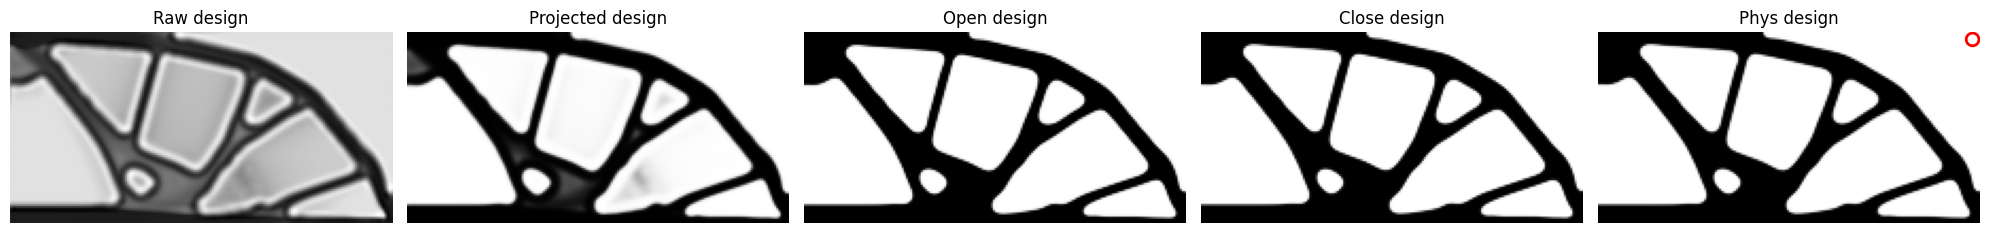

data/topopt_20260313_160634.pkl


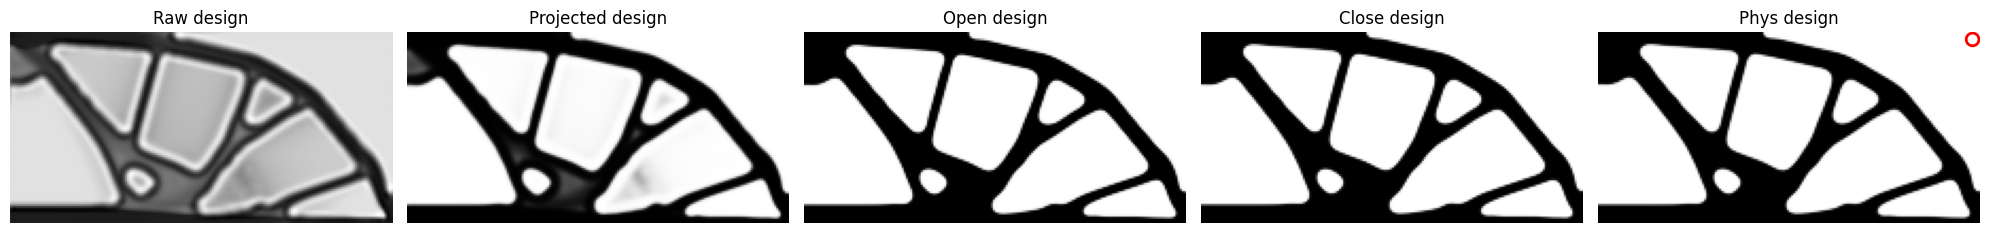

In [5]:
if True:
    final_density, history_fname = top(nelx=180, nely=90, volfrac=0.35, rmin=3.0, physics='elasticity', bc='mbb')
    print(history_fname)

 It.:  66 | Obj(norm):     0.0975 | Vol.(phys): 0.350(0.350) | Ch.: 0.014 | beta: 10.000 | Fab penalty: 0.025=0.025? (Fab tol: 0.025) | Switch: True


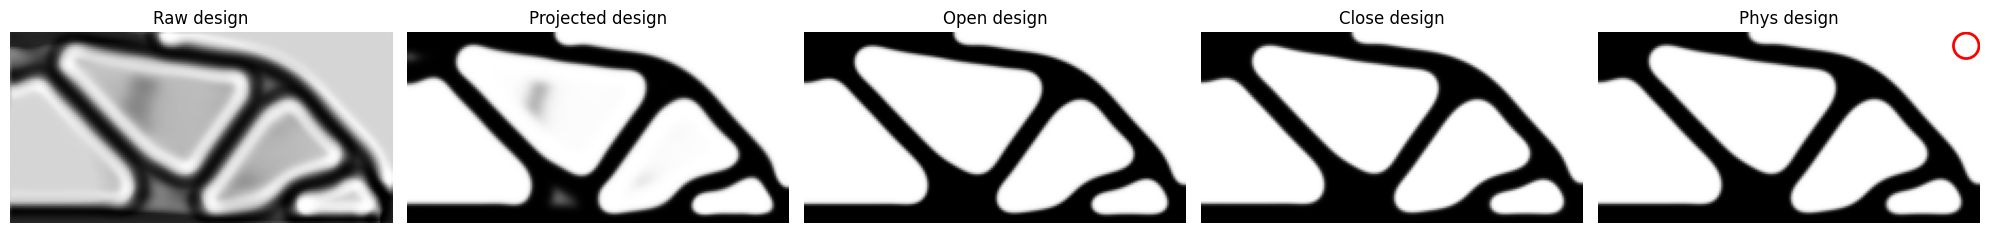

data/topopt_20260313_160809.pkl


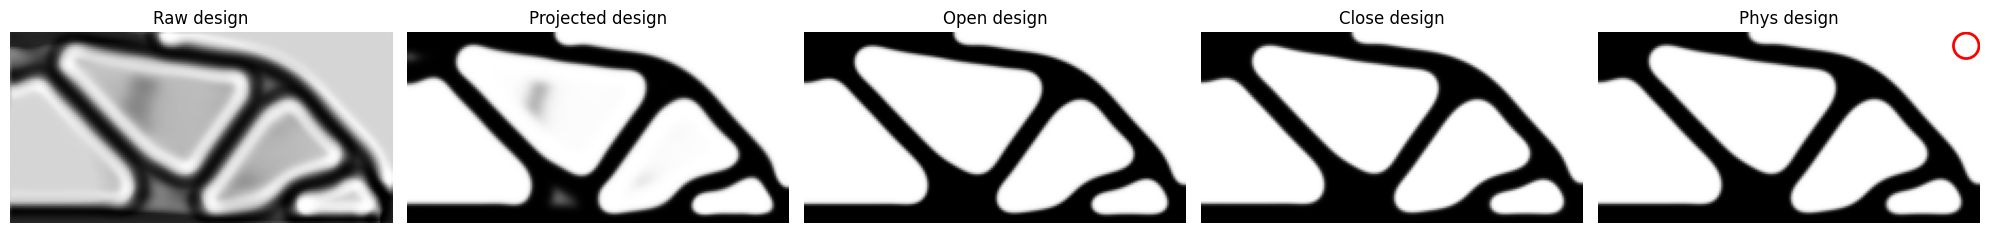

In [6]:
if True:
    final_density, history_fname = top(nelx=180, nely=90, volfrac=0.35, rmin=6.0, physics='elasticity', bc='mbb')
    print(history_fname)

 It.:  64 | Obj(norm):     0.1071 | Vol.(phys): 0.350(0.350) | Ch.: 0.019 | beta: 10.000 | Fab penalty: 0.025=0.025? (Fab tol: 0.025) | Switch: True


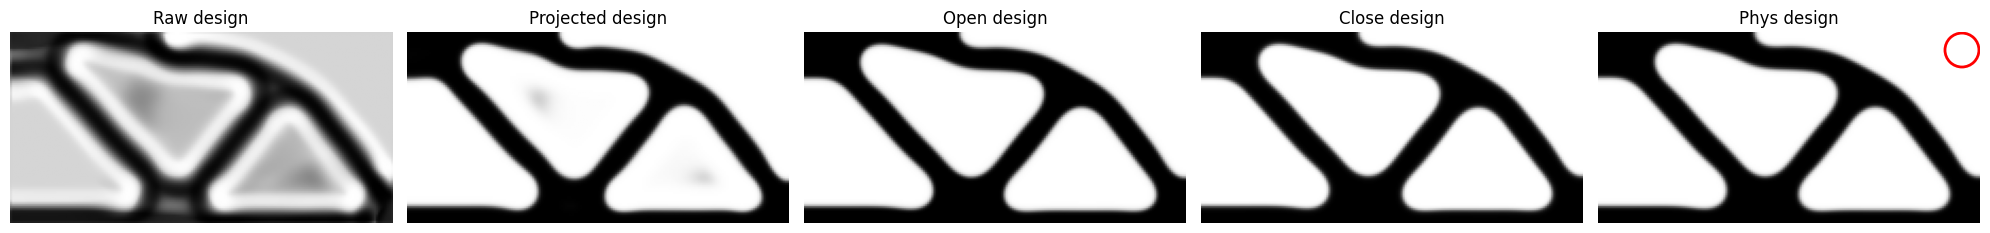

data/topopt_20260313_161123.pkl


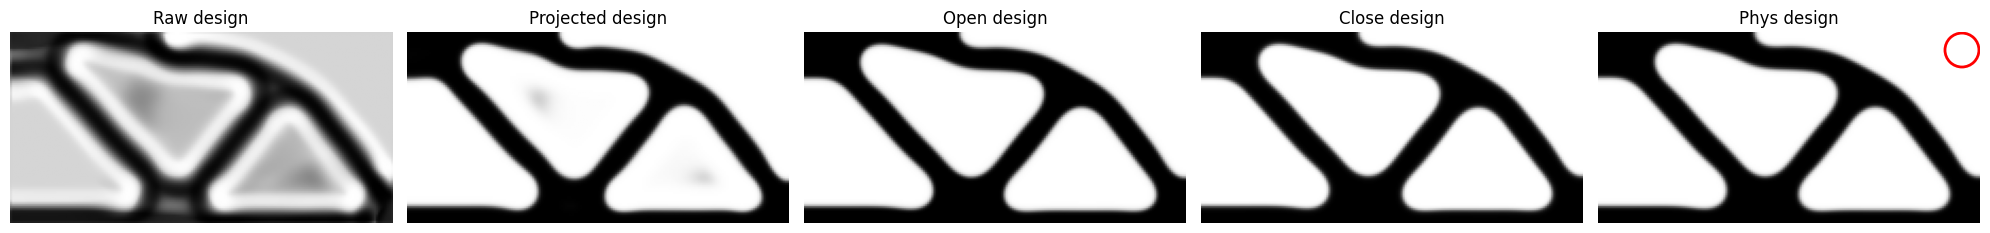

In [7]:
if True:
    final_density, history_fname = top(nelx=180, nely=90, volfrac=0.35, rmin=8.0, physics='elasticity', bc='mbb')
    print(history_fname)

 It.:  53 | Obj(norm):    -0.4006 | Vol.(phys): 0.300(0.300) | Ch.: 0.030 | beta: 10.000 | Fab penalty: 0.015=0.015? (Fab tol: 0.015) | Switch: True


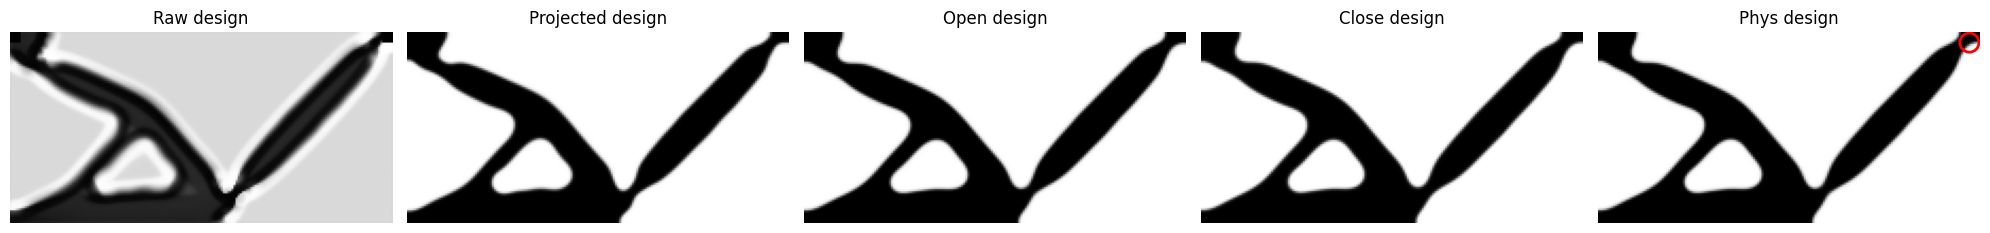

data/topopt_20260313_161330.pkl


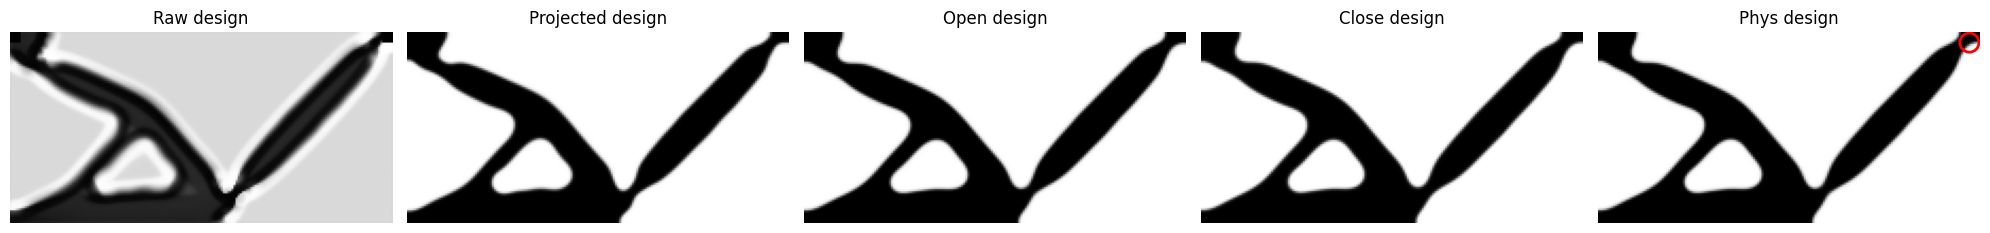

In [8]:
if True:
    final_density, history_fname = top(nelx=180, nely=90, volfrac=0.30, rmin=4.5, physics='elasticity', bc='mechanism',
    # custom setting
    fab_plateau_window=5,
    fab_plateau_rel_decline_tol=0.02,
    morph_blend=(1.0, 0.0),
    fab_tol_end=0.015,
    )
    print(history_fname)

 It.:  84 | Obj(norm):    39.3753 | Vol.(phys): 0.500(0.500) | Ch.: 0.028 | beta: 10.000 | Fab penalty: 0.025=0.025? (Fab tol: 0.025) | Switch: True


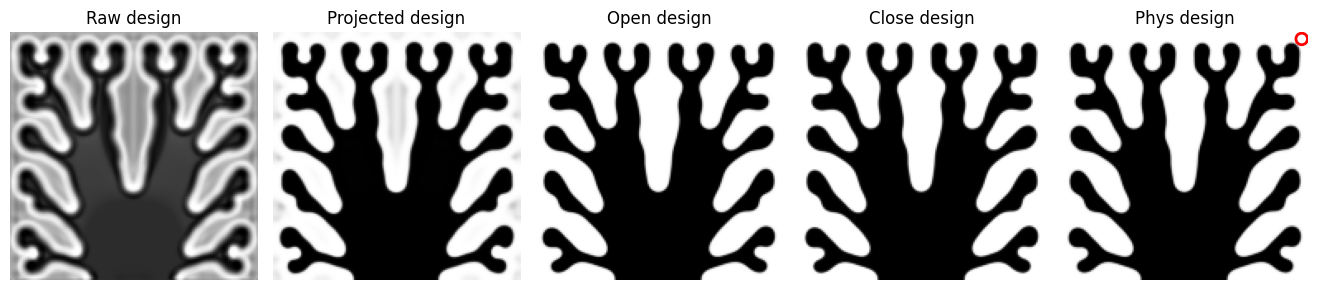

data/topopt_20260313_161507.pkl


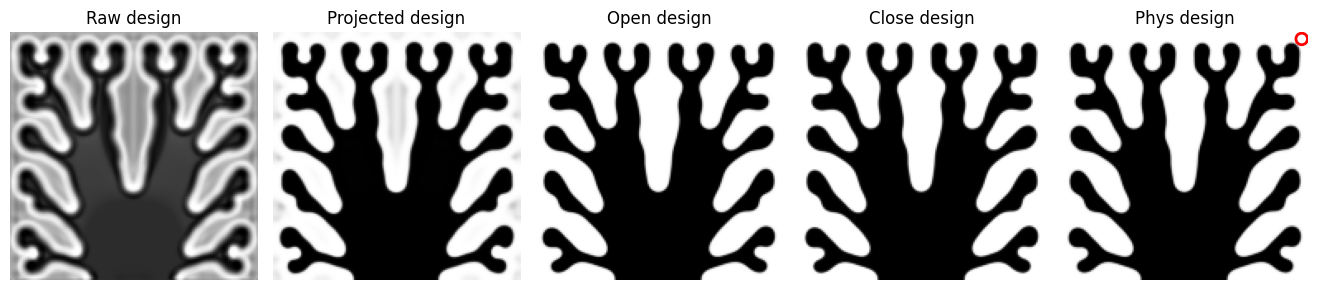

In [9]:
if True:
    final_density, history_fname = top(nelx=150, nely=150, volfrac=0.50, rmin=3.5, physics='thermal',
    # custom setting
    fab_plateau_window=5,
    fab_plateau_rel_decline_tol=0.02,
    morph_blend=(1.0, 0.0),
    )
    print(history_fname)